# RNA-Only Start-to-End Importance with Numba RWR

This notebook:
- Builds a **correlation-based RNA-only graph** using Gaussian soft thresholding with `sigma = 0.05`.
- Picks a source and sink node from the RNA network.
- Runs the **numba-accelerated random walk simulation** with `r = 0.5` (implemented as `restart_prob = 1 - r`).
- Keeps only successful walks that reach the sink.
- Computes the **expected number of hits** to each node (conditioned on successful walks).

In [10]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "DiffusionRWR_model_package").exists():
    raise RuntimeError(
        "Run this notebook from the DiffusionRWR_model_repo root directory so imports resolve."
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from DiffusionRWR_model_package.data_sorting import load_and_process_modelled_data
from DiffusionRWR_model_package.graph_generation.generate_graph_internal import generate_single_layer_graphs
from DiffusionRWR_model_package.graph_generation.edge_weight_functions import cor_gaussian_abs
from DiffusionRWR_model_package.run_RWR.numba_RWR import simulate_walks_FAST

In [11]:
datasets = load_and_process_modelled_data(histone_dataset_filter="all")
rna_data = datasets["rna_ai"].copy()

print(f"RNA dataset shape (genes x time points): {rna_data.shape}")
print(f"First 5 RNA nodes: {rna_data.index[:5].tolist()}")

Number of CSV files found: 4

CSV files found:
  - overlap_filtered_k20me3_m_v2.csv
  - overlap_filtered_k27me3_m_v2.csv
  - overlap_filtered_k9me2_m_v2.csv
  - overlap_filtered_rna_ai_m_v2.csv
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k20me3_m_v2' with shape: (657, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k27me3_m_v2' with shape: (650, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_k9me2_m_v2' with shape: (1001, 5) (row-wise standardized)
  Filtered to integer time points: ['0', '1', '2', '3', '4']
Imported 'overlap_filtered_rna_ai_m_v2' with shape: (384, 5) (row-wise standardized)

Successfully imported 4 datasets.
Available datasets: ['overlap_filtered_k20me3_m_v2', 'overlap_filtered_k27me3_m_v2', 'overlap_filtered_k9me2_m_v2', 'overlap_filtered_rna_ai_m_v2']
RNA dataset shape (genes x time points)

In [12]:
sigma = 0.05

adj_dict, sign_dict = generate_single_layer_graphs(
    {"rna_ai": rna_data},
    edge_fn=lambda df: cor_gaussian_abs(df, sigma=sigma),
    start=None,
    end=None,
    return_signs=True,
    threshold=0.01,
)

adjacency = adj_dict["rna_ai"].copy()

# Keep only RNA genes (drop basis vectors introduced by graph generator).
basis_nodes = {"e1", "e2", "e3", "e4", "e5"}
rna_nodes = [n for n in adjacency.index if n not in basis_nodes]
adjacency = adjacency.loc[rna_nodes, rna_nodes]

# Restrict to nodes with both incoming and outgoing connectivity.
row_sum = adjacency.sum(axis=1)
col_sum = adjacency.sum(axis=0)
connected_nodes = adjacency.index[(row_sum > 0) & (col_sum > 0)]
adjacency = adjacency.loc[connected_nodes, connected_nodes]

n = adjacency.shape[0]
possible_edges = n * (n - 1)
actual_edges = int((adjacency.values > 0).sum())
density = actual_edges / possible_edges if possible_edges > 0 else 0.0

print(f"RNA-only graph shape: {adjacency.shape}")
print(f"Non-zero directed edges: {actual_edges}")
print(f"Graph density: {density:.4f}")


Generating single-layer graph using edge function: <lambda>

--- Processing dataset: rna_ai ---
Data columns: ['0', '1', '2', '3', '4']
Basis vector e1: [ 2.  -0.5 -0.5 -0.5 -0.5]
Basis vector e2: [-0.5  2.  -0.5 -0.5 -0.5]
Basis vector e3: [-0.5 -0.5  2.  -0.5 -0.5]
Basis vector e4: [-0.5 -0.5 -0.5  2.  -0.5]
Basis vector e5: [-0.5 -0.5 -0.5 -0.5  2. ]
Data shape with basis vectors: (389, 5) (384 genes + 5 basis vectors)
Adjacency matrix shape: (389, 389)

Adjacency matrix statistics (<lambda>):
  Min: 0.000000
  Max: 1.000000
  Mean: 0.142592
  Median: 0.000000
RNA-only graph shape: (384, 384)
Non-zero directed edges: 44950
Graph density: 0.3056


In [13]:
# Pick deterministic source and sink from strongest connected RNA nodes.
out_strength = adjacency.sum(axis=1).sort_values(ascending=False)
in_strength = adjacency.sum(axis=0).sort_values(ascending=False)

if len(out_strength) < 2:
    raise RuntimeError("Need at least two connected RNA nodes to choose source and sink.")

source_node = out_strength.index[0]
sink_candidates = [node for node in in_strength.index if node != source_node]
if not sink_candidates:
    raise RuntimeError("Could not select a sink distinct from source.")
sink_node = sink_candidates[0]

print(f"Selected source node: {source_node}")
print(f"Selected sink node:   {sink_node}")

Selected source node: DMD
Selected sink node:   GREB1


In [14]:
# Random-walk configuration
r = 0.5
restart_prob = 1.0 - r
n_successful_walks = 1000

results, n_success, n_restart, n_total, successful_walks = simulate_walks_FAST(
    adj_matrix=adjacency,
    start=source_node,
    target=sink_node,
    restart_prob=restart_prob,
    n_sims=n_successful_walks,
)

print("\nSimulation summary:")
print(f"  r = {r}")
print(f"  restart_prob = {restart_prob}")
print(f"  successful walks collected = {n_success}")
print(f"  restarted attempts = {n_restart}")
print(f"  total attempts = {n_total}")


PROPERLY OPTIMIZED VERSION (CSR + Numba JIT)
Converting to CSR format for proper JIT compilation...
  ✓ CSR format: 384 nodes, 44950 edges
  ✓ Ready for JIT compilation!

First walk will compile JIT function (~1 second)
Then ALL subsequent walks will be 20-50x faster!

  Compiling JIT function...
  ✓ JIT compiled! Now running at FULL SPEED!
  Progress: 15/1000 successful walks (1000 attempts)
  Progress: 22/1000 successful walks (2000 attempts)
  Progress: 31/1000 successful walks (3000 attempts)
  Progress: 39/1000 successful walks (4000 attempts)
  Progress: 47/1000 successful walks (5000 attempts)
  Progress: 56/1000 successful walks (6000 attempts)
  Progress: 68/1000 successful walks (7000 attempts)
  Progress: 77/1000 successful walks (8000 attempts)
  Progress: 89/1000 successful walks (9000 attempts)
  Progress: 101/1000 successful walks (10000 attempts)
  Progress: 105/1000 successful walks (11000 attempts)
  Progress: 109/1000 successful walks (12000 attempts)
  Progress: 11

In [15]:
if len(successful_walks) == 0:
    raise RuntimeError("No successful walks reached sink; expected hits cannot be estimated.")

all_nodes = adjacency.index.tolist()
hit_rows = []

for walk in successful_walks:
    counts = pd.Series(walk["path"]).value_counts()
    hit_rows.append(counts.reindex(all_nodes, fill_value=0).astype(float))

hit_matrix = pd.DataFrame(hit_rows)

expected_hits = hit_matrix.mean(axis=0)
std_hits = hit_matrix.std(axis=0)
visit_probability = (hit_matrix > 0).mean(axis=0)

expected_hits_df = (
    pd.DataFrame({
        "node": expected_hits.index,
        "expected_hits_per_successful_walk": expected_hits.values,
        "std_hits_per_successful_walk": std_hits.reindex(expected_hits.index).values,
        "visit_probability": visit_probability.reindex(expected_hits.index).values,
    })
    .sort_values("expected_hits_per_successful_walk", ascending=False)
    .reset_index(drop=True)
)

expected_hits_df.head(25)

,node,expected_hits_per_successful_walk,std_hits_per_successful_walk,visit_probability
0,DMD,1.012,0.108940,1.000
1,GREB1,1.000,0.000000,1.000
2,ENTPD1,0.017,0.129336,0.017
3,FAM13C,0.016,0.125538,0.016
4,AKR1B10,0.016,0.125538,0.016
5,ERI3,0.016,0.125538,0.016
6,HADH,0.013,0.113331,0.013
7,A4GALT,0.013,0.113331,0.013
8,SERTAD4,0.013,0.113331,0.013
9,SLC5A8,0.012,0.108940,0.012


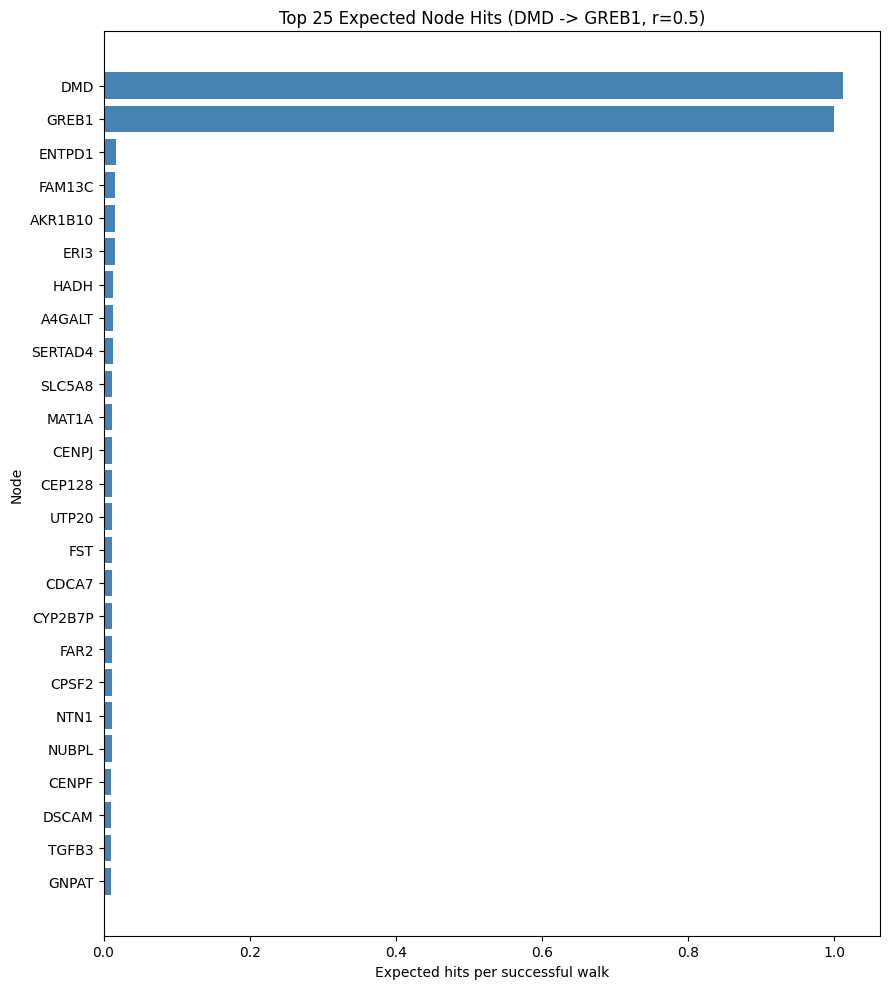

Saved expected-hit table to: C:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\Paper_results\rna_start_to_end_expected_hits_DMD_to_GREB1_r0p5.csv


In [16]:
top_n = 25
plot_df = expected_hits_df.head(top_n).iloc[::-1]

plt.figure(figsize=(9, 10))
plt.barh(plot_df["node"], plot_df["expected_hits_per_successful_walk"], color="steelblue")
plt.xlabel("Expected hits per successful walk")
plt.ylabel("Node")
plt.title(f"Top {top_n} Expected Node Hits ({source_node} -> {sink_node}, r={r})")
plt.tight_layout()
plt.show()

def safe_label(name):
    return "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in str(name))

output_dir = Path("Paper_results")
output_dir.mkdir(parents=True, exist_ok=True)

r_label = str(r).replace(".", "p")
csv_path = output_dir / (
    f"rna_start_to_end_expected_hits_{safe_label(source_node)}_to_{safe_label(sink_node)}_r{r_label}.csv"
)
expected_hits_df.to_csv(csv_path, index=False)

print(f"Saved expected-hit table to: {csv_path.resolve()}")

Comparison summary (Numba simulation vs linear algebra):
  Nodes compared: 384
  MAE (expected hits): 0.000864
  Max absolute diff: 0.008397
  Pearson correlation: 0.999721


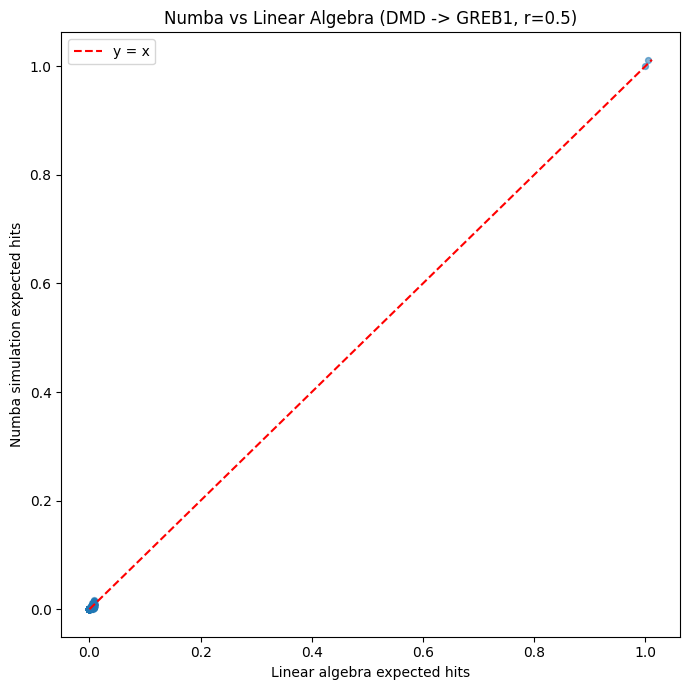

Saved comparison table to: C:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\Paper_results\rna_start_to_end_numba_vs_linear_DMD_to_GREB1_r0p5.csv


In [17]:
# Compare with the linear-algebra start-to-end formula used in implementation.ipynb

# Build the exact transition matrix used by numba_RWR preprocessing (weights > 0.001, row-normalized).
min_weight_numba = 0.001
transition = pd.DataFrame(0.0, index=adjacency.index, columns=adjacency.columns)

for node in adjacency.index:
    row = adjacency.loc[node]
    nz = row > min_weight_numba
    if nz.any():
        vals = row[nz]
        transition.loc[node, vals.index] = vals / vals.sum()


def start_to_end_path_linear_algebra(graph, start, end, r=0.5):
    """
    Linear algebra formula extracted from implementation.ipynb (start_to_end_path).
    Returns conditional expected hits for non-sink nodes.
    """
    if not isinstance(graph, pd.DataFrame):
        raise TypeError("graph must be a pandas DataFrame")

    nodes = graph.index

    if isinstance(start, str):
        if start not in nodes:
            raise ValueError(f"start node '{start}' not found in graph")
        start_idx = nodes.get_loc(start)
    else:
        start_idx = int(start)

    if isinstance(end, str):
        if end not in nodes:
            raise ValueError(f"end node '{end}' not found in graph")
        end_idx = nodes.get_loc(end)
    else:
        end_idx = int(end)

    if start_idx == end_idx:
        raise ValueError("start and end must be different nodes")

    A = graph.to_numpy(dtype=float)
    Q = r * A

    keep = np.ones(Q.shape[0], dtype=bool)
    keep[end_idx] = False

    Q_wo_end = Q[np.ix_(keep, keep)]
    q_to_end = Q[keep, end_idx]

    G = np.linalg.inv(np.eye(Q_wo_end.shape[0]) - Q_wo_end)
    h = G @ q_to_end

    kept_indices = np.where(keep)[0]
    start_reduced_idx = int(np.where(kept_indices == start_idx)[0][0])

    if np.isclose(h[start_reduced_idx], 0.0):
        raise ValueError("h(start) is zero; cannot normalize start-to-end importance")

    R = (h * G[start_reduced_idx, :]) / h[start_reduced_idx]
    return pd.Series(R, index=nodes[keep], name="start_to_end_importance").sort_values(ascending=False)


linear_non_sink = start_to_end_path_linear_algebra(
    graph=transition,
    start=source_node,
    end=sink_node,
    r=r,
)

# Add sink hit count for comparability with simulation paths (first-hit stopping gives sink exactly one hit).
linear_hits = linear_non_sink.reindex(adjacency.index, fill_value=0.0).astype(float)
linear_hits.loc[sink_node] = 1.0

# Numba estimate from successful trajectories
numba_hits = expected_hits.reindex(adjacency.index, fill_value=0.0).astype(float)

comparison_df = pd.DataFrame({
    "node": adjacency.index,
    "expected_hits_numba": numba_hits.values,
    "expected_hits_linear_algebra": linear_hits.reindex(adjacency.index).values,
}).set_index("node")

comparison_df["abs_diff"] = (
    comparison_df["expected_hits_numba"] - comparison_df["expected_hits_linear_algebra"]
).abs()
den = np.maximum(np.abs(comparison_df["expected_hits_linear_algebra"].values), 1e-12)
comparison_df["rel_diff"] = comparison_df["abs_diff"].values / den
comparison_df["rank_numba"] = comparison_df["expected_hits_numba"].rank(ascending=False, method="min")
comparison_df["rank_linear"] = comparison_df["expected_hits_linear_algebra"].rank(ascending=False, method="min")
comparison_df["rank_diff"] = (comparison_df["rank_numba"] - comparison_df["rank_linear"]).abs()

mae = comparison_df["abs_diff"].mean()
max_abs_diff = comparison_df["abs_diff"].max()
pearson_corr = np.corrcoef(
    comparison_df["expected_hits_numba"].values,
    comparison_df["expected_hits_linear_algebra"].values,
)[0, 1]

print("Comparison summary (Numba simulation vs linear algebra):")
print(f"  Nodes compared: {len(comparison_df)}")
print(f"  MAE (expected hits): {mae:.6f}")
print(f"  Max absolute diff: {max_abs_diff:.6f}")
print(f"  Pearson correlation: {pearson_corr:.6f}")

top_disagreements = comparison_df.sort_values("abs_diff", ascending=False).head(25)
top_disagreements

plt.figure(figsize=(7, 7))
x = comparison_df["expected_hits_linear_algebra"].values
y = comparison_df["expected_hits_numba"].values
plt.scatter(x, y, alpha=0.55, s=18)
max_val = max(float(np.max(x)), float(np.max(y)), 1e-12)
plt.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="y = x")
plt.xlabel("Linear algebra expected hits")
plt.ylabel("Numba simulation expected hits")
plt.title(f"Numba vs Linear Algebra ({source_node} -> {sink_node}, r={r})")
plt.legend()
plt.tight_layout()
plt.show()

if "safe_label" not in globals():
    def safe_label(name):
        return "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in str(name))

if "output_dir" not in globals():
    output_dir = Path("Paper_results")
    output_dir.mkdir(parents=True, exist_ok=True)

r_label = str(r).replace(".", "p")
comparison_csv_path = output_dir / (
    f"rna_start_to_end_numba_vs_linear_{safe_label(source_node)}_to_{safe_label(sink_node)}_r{r_label}.csv"
 )
comparison_df.reset_index().to_csv(comparison_csv_path, index=False)
print(f"Saved comparison table to: {comparison_csv_path.resolve()}")

In [18]:
# Run the same numba-vs-linear comparison on a random set of source/sink pairs.
rng_seed = 20260604
rng = np.random.default_rng(rng_seed)
target_pairs = 20
n_sims_batch = 500
max_pair_draws = 2000

nodes = adjacency.index.to_numpy()
seen_pairs = set()
batch_records = []
pair_examples = []

for _ in range(max_pair_draws):
    if len(batch_records) >= target_pairs:
        break

    src, sink = rng.choice(nodes, size=2, replace=False)
    src = str(src)
    sink = str(sink)
    pair = (src, sink)

    if pair in seen_pairs:
        continue
    seen_pairs.add(pair)

    try:
        la_non_sink_i = start_to_end_path_linear_algebra(transition, src, sink, r=r)
    except Exception:
        continue

    linear_hits_i = la_non_sink_i.reindex(adjacency.index, fill_value=0.0).astype(float)
    linear_hits_i.loc[sink] = 1.0

    _, n_success_i, n_restart_i, n_total_i, successful_i = simulate_walks_FAST(
        adj_matrix=adjacency,
        start=src,
        target=sink,
        restart_prob=restart_prob,
        n_sims=n_sims_batch,
    )

    if len(successful_i) == 0:
        continue

    hit_rows_i = []
    for walk_i in successful_i:
        counts_i = pd.Series(walk_i["path"]).value_counts()
        hit_rows_i.append(counts_i.reindex(adjacency.index, fill_value=0).astype(float))
    hit_matrix_i = pd.DataFrame(hit_rows_i)
    numba_hits_i = hit_matrix_i.mean(axis=0).astype(float)

    cmp_i = pd.DataFrame({
        "numba": numba_hits_i.reindex(adjacency.index),
        "linear": linear_hits_i.reindex(adjacency.index),
    })
    cmp_i["abs_diff"] = (cmp_i["numba"] - cmp_i["linear"]).abs()

    corr_i = np.corrcoef(cmp_i["numba"].values, cmp_i["linear"].values)[0, 1]
    if np.isnan(corr_i):
        corr_i = 0.0

    batch_records.append({
        "source_node": src,
        "sink_node": sink,
        "successful_walks": int(n_success_i),
        "restarted_attempts": int(n_restart_i),
        "total_attempts": int(n_total_i),
        "restart_rate": float(n_restart_i / n_total_i) if n_total_i else np.nan,
        "mae": float(cmp_i["abs_diff"].mean()),
        "max_abs_diff": float(cmp_i["abs_diff"].max()),
        "pearson_corr": float(corr_i),
    })

    pair_examples.append(
        cmp_i.sort_values("abs_diff", ascending=False)
        .head(5)
        .assign(source_node=src, sink_node=sink)
        .reset_index()
        .rename(columns={"index": "node"})
    )

batch_summary_df = pd.DataFrame(batch_records)

if batch_summary_df.empty:
    raise RuntimeError("No valid source/sink pairs were completed.")

batch_summary_df = batch_summary_df.sort_values("mae").reset_index(drop=True)

print(f"Random seed: {rng_seed}")
print(f"Requested pairs: {target_pairs}")
print(f"Completed pairs: {len(batch_summary_df)}")
if len(batch_summary_df) < target_pairs:
    print(f"Warning: only {len(batch_summary_df)} valid pairs found within {max_pair_draws} random draws.")

print("\nAggregate metrics across completed pairs:")
print(f"  Mean MAE: {batch_summary_df['mae'].mean():.6f}")
print(f"  Median MAE: {batch_summary_df['mae'].median():.6f}")
print(f"  Mean Pearson correlation: {batch_summary_df['pearson_corr'].mean():.6f}")
print(f"  Min Pearson correlation: {batch_summary_df['pearson_corr'].min():.6f}")
print(f"  Max Pearson correlation: {batch_summary_df['pearson_corr'].max():.6f}")

if "output_dir" not in globals():
    output_dir = Path("Paper_results")
    output_dir.mkdir(parents=True, exist_ok=True)

r_label_batch = str(r).replace(".", "p")
batch_csv = output_dir / f"rna_random_pairs_numba_vs_linear_summary_{len(batch_summary_df)}pairs_r{r_label_batch}.csv"
batch_summary_df.to_csv(batch_csv, index=False)
print(f"\nSaved batch summary to: {batch_csv.resolve()}")

if pair_examples:
    examples_df = pd.concat(pair_examples, ignore_index=True)
    examples_csv = output_dir / f"rna_random_pairs_numba_vs_linear_topdiff_nodes_{len(batch_summary_df)}pairs_r{r_label_batch}.csv"
    examples_df.to_csv(examples_csv, index=False)
    print(f"Saved top-node disagreements to: {examples_csv.resolve()}")

batch_summary_df


PROPERLY OPTIMIZED VERSION (CSR + Numba JIT)
Converting to CSR format for proper JIT compilation...
  ✓ CSR format: 384 nodes, 44950 edges
  ✓ Ready for JIT compilation!

First walk will compile JIT function (~1 second)
Then ALL subsequent walks will be 20-50x faster!

  Compiling JIT function...
  ✓ JIT compiled! Now running at FULL SPEED!
  Progress: 0/500 successful walks (1000 attempts)
  Progress: 3/500 successful walks (2000 attempts)
  Progress: 5/500 successful walks (3000 attempts)
  Progress: 5/500 successful walks (4000 attempts)
  Progress: 6/500 successful walks (5000 attempts)
  Progress: 9/500 successful walks (6000 attempts)
  Progress: 9/500 successful walks (7000 attempts)
  Progress: 9/500 successful walks (8000 attempts)
  Progress: 10/500 successful walks (9000 attempts)
  Progress: 13/500 successful walks (10000 attempts)
  Progress: 13/500 successful walks (11000 attempts)
  Progress: 13/500 successful walks (12000 attempts)
  Progress: 14/500 successful walks (

,source_node,sink_node,successful_walks,restarted_attempts,total_attempts,restart_rate,mae,max_abs_diff,pearson_corr
0,PLEKHO1,SESN3,500,111074,111574,0.995519,0.000465,0.025332,0.999750
1,VAC14,PTPRZ1,500,35326,35826,0.986044,0.000714,0.018435,0.999455
2,ANP32A,FAM174B,500,54255,54755,0.990868,0.000855,0.012813,0.999660
3,ARHGEF6,RAD18,500,50638,51138,0.990223,0.000961,0.009353,0.999658
4,LMO7,FGF1,500,95240,95740,0.994778,0.001181,0.014643,0.999270
5,SMPD3,CADM1,500,143359,143859,0.996524,0.001219,0.022862,0.999196
6,FST,CDHR3,500,153690,154190,0.996757,0.001244,0.013752,0.999409
7,ANO10,GPR176,500,1007894,1008394,0.999504,0.001294,0.037287,0.998398
8,FMNL2,HECTD1,500,3818425,3818925,0.999869,0.001334,0.036351,0.998743
9,NBAS,SGPP2,500,1236237,1236737,0.999596,0.001385,0.042034,0.998675


In [19]:
# Recompute linear-algebra results for all sampled pairs and compare node-by-node vs numba.
if "batch_summary_df" not in globals() or batch_summary_df.empty:
    raise RuntimeError("Run the random-pair batch cell first to create batch_summary_df.")

pairs_to_compare = batch_summary_df[["source_node", "sink_node"]].drop_duplicates().reset_index(drop=True)
n_sims_compare = int(n_sims_batch) if "n_sims_batch" in globals() else 500

node_level_rows = []
pair_level_rows = []

for _, pair_row in pairs_to_compare.iterrows():
    src = pair_row["source_node"]
    sink = pair_row["sink_node"]

    la_non_sink_i = start_to_end_path_linear_algebra(transition, src, sink, r=r)
    linear_hits_i = la_non_sink_i.reindex(adjacency.index, fill_value=0.0).astype(float)
    linear_hits_i.loc[sink] = 1.0

    _, n_success_i, n_restart_i, n_total_i, successful_i = simulate_walks_FAST(
        adj_matrix=adjacency,
        start=src,
        target=sink,
        restart_prob=restart_prob,
        n_sims=n_sims_compare,
    )

    if len(successful_i) == 0:
        continue

    hit_rows_i = []
    for walk_i in successful_i:
        counts_i = pd.Series(walk_i["path"]).value_counts()
        hit_rows_i.append(counts_i.reindex(adjacency.index, fill_value=0).astype(float))
    hit_matrix_i = pd.DataFrame(hit_rows_i)
    numba_hits_i = hit_matrix_i.mean(axis=0).astype(float)

    cmp_i = pd.DataFrame({
        "node": adjacency.index,
        "numba_hits": numba_hits_i.reindex(adjacency.index).values,
        "linear_hits": linear_hits_i.reindex(adjacency.index).values,
    }).set_index("node")

    cmp_i["abs_diff"] = (cmp_i["numba_hits"] - cmp_i["linear_hits"]).abs()
    cmp_i["rank_numba"] = cmp_i["numba_hits"].rank(ascending=False, method="min")
    cmp_i["rank_linear"] = cmp_i["linear_hits"].rank(ascending=False, method="min")
    cmp_i["rank_diff"] = (cmp_i["rank_numba"] - cmp_i["rank_linear"]).abs()

    pearson_i = np.corrcoef(cmp_i["numba_hits"].values, cmp_i["linear_hits"].values)[0, 1]
    if np.isnan(pearson_i):
        pearson_i = 0.0
    spearman_i = cmp_i["numba_hits"].corr(cmp_i["linear_hits"], method="spearman")
    if pd.isna(spearman_i):
        spearman_i = 0.0

    pair_level_rows.append({
        "source_node": src,
        "sink_node": sink,
        "successful_walks": int(n_success_i),
        "restarted_attempts": int(n_restart_i),
        "total_attempts": int(n_total_i),
        "restart_rate": float(n_restart_i / n_total_i) if n_total_i else np.nan,
        "mae": float(cmp_i["abs_diff"].mean()),
        "max_abs_diff": float(cmp_i["abs_diff"].max()),
        "pearson_corr": float(pearson_i),
        "spearman_corr": float(spearman_i),
    })

    cmp_export = cmp_i.reset_index()
    cmp_export["source_node"] = src
    cmp_export["sink_node"] = sink
    node_level_rows.append(cmp_export)

if not pair_level_rows:
    raise RuntimeError("No valid pair comparisons were completed.")

all_pairs_summary_df = pd.DataFrame(pair_level_rows).sort_values("mae").reset_index(drop=True)
all_pairs_node_comparison_df = pd.concat(node_level_rows, ignore_index=True)

print(f"Pairs compared: {len(all_pairs_summary_df)}")
print(f"Nodes per pair: {adjacency.shape[0]}")
print(f"Mean MAE: {all_pairs_summary_df['mae'].mean():.6f}")
print(f"Median MAE: {all_pairs_summary_df['mae'].median():.6f}")
print(f"Mean Pearson corr: {all_pairs_summary_df['pearson_corr'].mean():.6f}")
print(f"Mean Spearman corr: {all_pairs_summary_df['spearman_corr'].mean():.6f}")

if "output_dir" not in globals():
    output_dir = Path("Paper_results")
    output_dir.mkdir(parents=True, exist_ok=True)

r_label_batch = str(r).replace(".", "p")
summary_csv_all = output_dir / f"rna_random_pairs_full_comparison_summary_{len(all_pairs_summary_df)}pairs_r{r_label_batch}.csv"
nodes_csv_all = output_dir / f"rna_random_pairs_full_comparison_node_level_{len(all_pairs_summary_df)}pairs_r{r_label_batch}.csv"
all_pairs_summary_df.to_csv(summary_csv_all, index=False)
all_pairs_node_comparison_df.to_csv(nodes_csv_all, index=False)

print(f"Saved pair-level summary to: {summary_csv_all.resolve()}")
print(f"Saved node-level comparison to: {nodes_csv_all.resolve()}")

all_pairs_summary_df


PROPERLY OPTIMIZED VERSION (CSR + Numba JIT)
Converting to CSR format for proper JIT compilation...
  ✓ CSR format: 384 nodes, 44950 edges
  ✓ Ready for JIT compilation!

First walk will compile JIT function (~1 second)
Then ALL subsequent walks will be 20-50x faster!

  Compiling JIT function...
  ✓ JIT compiled! Now running at FULL SPEED!
  Progress: 3/500 successful walks (1000 attempts)
  Progress: 9/500 successful walks (2000 attempts)
  Progress: 13/500 successful walks (3000 attempts)
  Progress: 16/500 successful walks (4000 attempts)
  Progress: 23/500 successful walks (5000 attempts)
  Progress: 30/500 successful walks (6000 attempts)
  Progress: 40/500 successful walks (7000 attempts)
  Progress: 46/500 successful walks (8000 attempts)
  Progress: 51/500 successful walks (9000 attempts)
  Progress: 60/500 successful walks (10000 attempts)
  Progress: 63/500 successful walks (11000 attempts)
  Progress: 66/500 successful walks (12000 attempts)
  Progress: 68/500 successful w

,source_node,sink_node,successful_walks,restarted_attempts,total_attempts,restart_rate,mae,max_abs_diff,pearson_corr,spearman_corr
0,PLEKHO1,SESN3,500,110604,111104,0.995500,0.000533,0.019366,0.999711,0.511889
1,VAC14,PTPRZ1,500,41986,42486,0.988231,0.000610,0.019528,0.999563,0.600628
2,ANP32A,FAM174B,500,49180,49680,0.989936,0.000894,0.010130,0.999666,0.689953
3,ARHGEF6,RAD18,500,51570,52070,0.990398,0.001018,0.010917,0.999584,0.802070
4,LMO7,FGF1,500,101314,101814,0.995089,0.001079,0.015925,0.999336,0.786680
5,SMPD3,CADM1,500,144417,144917,0.996550,0.001149,0.017222,0.999327,0.825047
6,ANO10,GPR176,500,1035328,1035828,0.999517,0.001292,0.040946,0.998294,0.657598
7,FST,CDHR3,500,143071,143571,0.996517,0.001332,0.010509,0.999363,0.845433
8,ZNF185,ANKRD6,500,371885,372385,0.998657,0.001392,0.022640,0.999065,0.820158
9,TANC1,IL17RD,500,4958959,4959459,0.999899,0.001477,0.041949,0.998244,0.739689


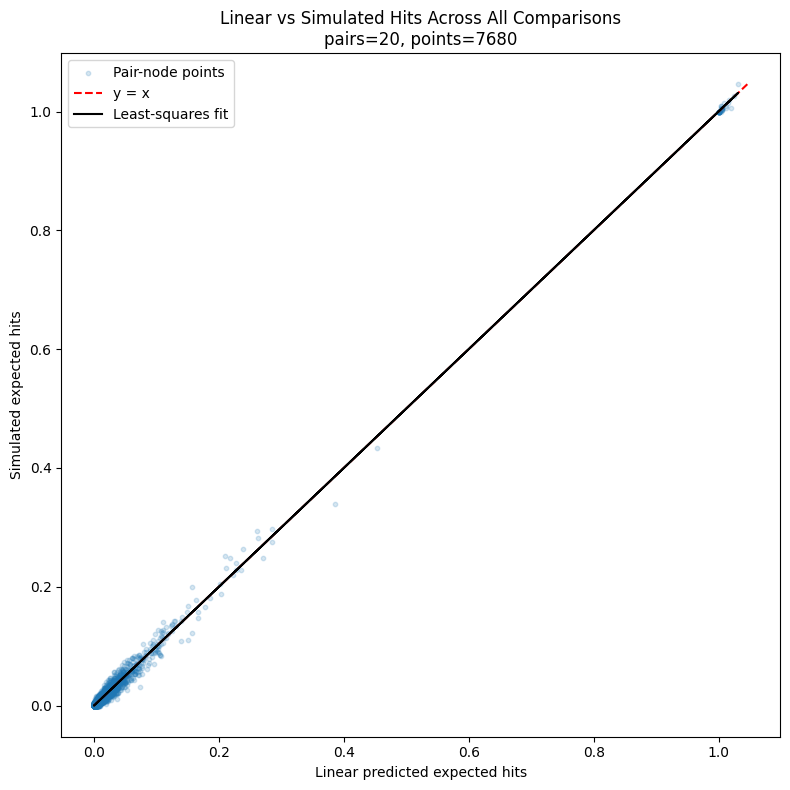

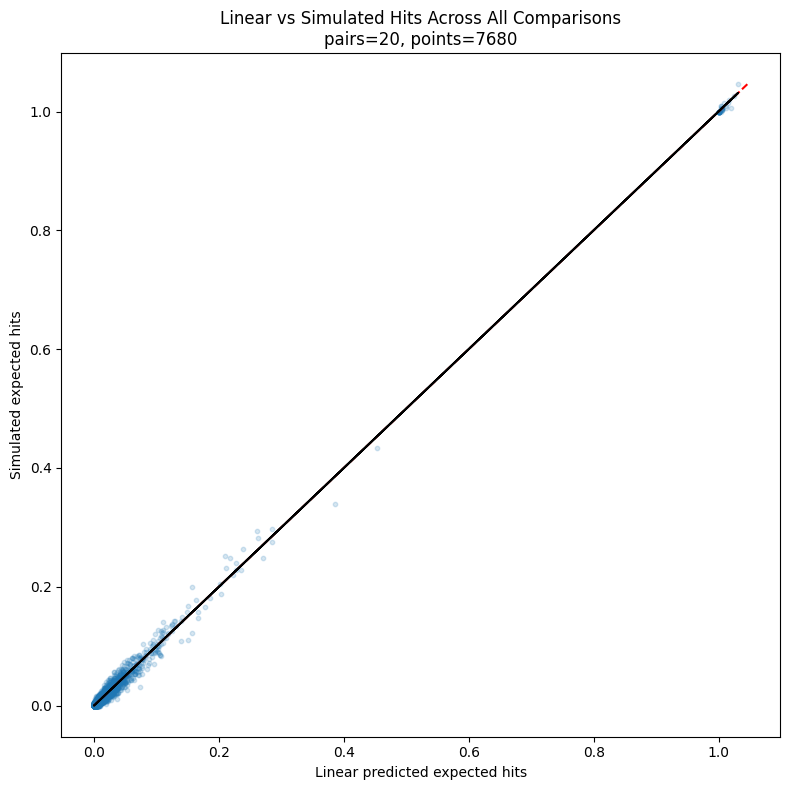

Total compared points: 7680
Pearson correlation: 0.998825
Spearman correlation: 0.819654
Linear fit: simulated ~= 1.000185 * linear + -0.000015
Saved extracted results to: C:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\Paper_results\rna_all_pairs_extracted_results_20pairs_r0p5.csv
Saved scatter plot to: C:\Users\inigo\OneDrive\Documents\Fourth_Year\Computations\Dissertation\DiffusionRWR_model_repo\Paper_results\rna_all_pairs_linear_vs_simulated_20pairs_r0p5.png


,source_node,sink_node,node,linear_hits,numba_hits,abs_diff,rank_linear,rank_numba,rank_diff
0,PLEKHO1,SESN3,A4GALT,8.484759e-05,0.000,8.484759e-05,154.0,50.0,104.0
1,PLEKHO1,SESN3,ACE,2.343221e-05,0.000,2.343221e-05,264.0,50.0,214.0
2,PLEKHO1,SESN3,ACTR3B,3.449978e-03,0.004,5.500218e-04,21.0,19.0,2.0
3,PLEKHO1,SESN3,ADAMTS19,4.817323e-05,0.000,4.817323e-05,209.0,50.0,159.0
4,PLEKHO1,SESN3,ADD3,6.480997e-05,0.000,6.480997e-05,181.0,50.0,131.0
5,PLEKHO1,SESN3,ADGRA3,7.119470e-03,0.004,3.119470e-03,14.0,19.0,5.0
6,PLEKHO1,SESN3,ADGRF3,3.004666e-05,0.000,3.004666e-05,249.0,50.0,199.0
7,PLEKHO1,SESN3,AFAP1L2,3.879352e-07,0.000,3.879352e-07,344.0,50.0,294.0
8,PLEKHO1,SESN3,AK4,4.663338e-04,0.000,4.663338e-04,67.0,50.0,17.0
9,PLEKHO1,SESN3,AK9,4.294168e-06,0.000,4.294168e-06,308.0,50.0,258.0


In [ ]:
# Extract results and create a publication-ready linear-vs-simulated plot.
if "all_pairs_node_comparison_df" not in globals() or all_pairs_node_comparison_df.empty:
    raise RuntimeError("Run the all-pairs comparison cell first to create all_pairs_node_comparison_df.")

extracted_results_df = all_pairs_node_comparison_df.copy()
extracted_results_df = extracted_results_df[[
    "source_node",
    "sink_node",
    "node",
    "linear_hits",
    "numba_hits",
    "abs_diff",
    "rank_linear",
    "rank_numba",
    "rank_diff",
]]

x_all = extracted_results_df["linear_hits"].to_numpy(dtype=float)
y_all = extracted_results_df["numba_hits"].to_numpy(dtype=float)

pearson_all = np.corrcoef(x_all, y_all)[0, 1]
if np.isnan(pearson_all):
    pearson_all = 0.0
spearman_all = extracted_results_df["linear_hits"].corr(extracted_results_df["numba_hits"], method="spearman")
if pd.isna(spearman_all):
    spearman_all = 0.0

slope, intercept = np.polyfit(x_all, y_all, deg=1)
y_fit = slope * x_all + intercept
ss_res = float(np.sum((y_all - y_fit) ** 2))
ss_tot = float(np.sum((y_all - np.mean(y_all)) ** 2))
r2_all = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan

n_points = len(x_all)
x_bar = float(np.mean(x_all))
sxx = float(np.sum((x_all - x_bar) ** 2))
max_all = max(float(np.max(x_all)), float(np.max(y_all)), 1e-12)
x_line = np.linspace(0.0, max_all, 300)
y_line = slope * x_line + intercept

if n_points > 2 and sxx > 0:
    s_err = np.sqrt(ss_res / (n_points - 2))
    ci = 1.96 * s_err * np.sqrt(1.0 / n_points + ((x_line - x_bar) ** 2) / sxx)
else:
    ci = np.zeros_like(x_line)

if "output_dir" not in globals():
    output_dir = Path("Paper_results")
    output_dir.mkdir(parents=True, exist_ok=True)

r_label_all = str(r).replace(".", "p")
results_csv = output_dir / f"rna_all_pairs_extracted_results_{len(all_pairs_summary_df)}pairs_r{r_label_all}.csv"
plot_png = output_dir / f"rna_all_pairs_linear_vs_simulated_publication_{len(all_pairs_summary_df)}pairs_r{r_label_all}.png"
plot_pdf = output_dir / f"rna_all_pairs_linear_vs_simulated_publication_{len(all_pairs_summary_df)}pairs_r{r_label_all}.pdf"
plot_svg = output_dir / f"rna_all_pairs_linear_vs_simulated_publication_{len(all_pairs_summary_df)}pairs_r{r_label_all}.svg"

extracted_results_df.to_csv(results_csv, index=False)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, ax = plt.subplots(figsize=(7.0, 6.6), dpi=200)
hb = ax.hexbin(
    x_all,
    y_all,
    gridsize=65,
    mincnt=1,
    cmap="Blues",
    linewidths=0.0,
    alpha=0.95,
 )
cbar = fig.colorbar(hb, ax=ax, pad=0.015)
cbar.set_label("Point count per hex bin")

ax.plot([0.0, max_all], [0.0, max_all], linestyle="--", color="firebrick", linewidth=1.8, label="Identity (y = x)")
ax.plot(x_line, y_line, color="black", linewidth=2.0, label="Linear fit")
ax.fill_between(x_line, y_line - ci, y_line + ci, color="gray", alpha=0.18, linewidth=0.0, label="95% CI (fit)")

ax.set_xlim(0.0, max_all * 1.02)
ax.set_ylim(0.0, max_all * 1.02)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Linear predicted expected hits")
ax.set_ylabel("Simulated expected hits")
ax.set_title("Linear Prediction vs Numba Simulation Across All Pair-Node Comparisons")

metrics_text = (
    f"Pairs: {len(all_pairs_summary_df)}\\n"
    f"Points: {n_points}\\n"
    f"Pearson r: {pearson_all:.3f}\\n"
    f"Spearman rho: {spearman_all:.3f}\\n"
    f"R^2: {r2_all:.3f}\\n"
    f"Fit: y = {slope:.3f}x + {intercept:.3f}"
 )
ax.text(
    0.03,
    0.97,
    metrics_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "0.4", "alpha": 0.95},
 )

ax.legend(loc="lower right", frameon=True)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

fig.savefig(plot_png, dpi=600, bbox_inches="tight")
fig.savefig(plot_pdf, bbox_inches="tight")
fig.savefig(plot_svg, bbox_inches="tight")
plt.show()

print(f"Total compared points: {n_points}")
print(f"Pearson correlation: {pearson_all:.6f}")
print(f"Spearman correlation: {spearman_all:.6f}")
print(f"Linear fit: simulated ~= {slope:.6f} * linear + {intercept:.6f}")
print(f"Saved extracted results to: {results_csv.resolve()}")
print(f"Saved publication PNG to: {plot_png.resolve()}")
print(f"Saved publication PDF to: {plot_pdf.resolve()}")
print(f"Saved publication SVG to: {plot_svg.resolve()}")

extracted_results_df.head(20)